# Supplementary Figure 3

*Carvalho, Cojocaru and Fukai (2026)*

**See also:** `figure4_upload.ipynb` (results with `alpha` = 0.0693).

## 📌 User input: start here!

### 1️⃣ Exponential gap penalty

Supplementary figures use `alpha` (allowed spike-time jitter) = 0.1386 (5 ms).

### 2️⃣ Date

This notebook requires the output `run_all.py` and `movement_classes.py`. After verifying that both scripts have run, update the date of the result folder.

In [ ]:
alpha = "0.1386"
date_str = "20XX-XX-XX"

## Imports

In [4]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from ast import literal_eval
from statannotations.Annotator import Annotator

from import_data import import_run_all
from plot_style import *

sessions = ["071102", "071107", "071109", "071213", 
            "071214", "071218", "071221", "071227", 
            "080213", "071228", "080206", "080208", 
            "080227", "080220", "080222"]

file_name = "run_all"
path_local = "../"

path_in = path_local + "results/" + date_str + "/" + file_name + "/"

path_out = path_local + "results/" + date_str + "/paper_plots/"
if not os.path.exists(path_out):
    os.makedirs(path_out)

path_plots = path_out + f"figure4_alpha{alpha}/"
if not os.path.exists(path_plots):
    os.makedirs(path_plots)

path_out_movement = path_local + "results/movement_classes/"

(
    df_stage,
    df_comparison,
    df_neuron_concat,
    df_edge_concat,
    df_profile_concat,
    df_reward_concat_full,
    df_reward_combined_concat_full,
    df_reward_concat_prof_len,
) = import_run_all(
    sessions,
    alpha,
    path_in,
    path_out_movement,
    export=True,
)

## Helpers

In [5]:
class TestChoice:
    def __init__(self, name: str, kwargs: dict):
        self.name = name
        self.kwargs = kwargs


def plot_paired_boxplot(df, column, export_name, test_choice, path_plots, swarm=True, lines=True):
    fig, ax = plt.subplots(1, 1, figsize=(2.5, 4))

    fig_args = {
        'x': 'Stage',
        'y': column,
        'data': df,
        'order': ["Early", "Late"],
        'hue': 'Stage',
        'linewidth': 2.5,
        'palette': palette_early_late,
        'flierprops': {
            "marker": "x", 
            "markersize": 12, 
            "markerfacecolor": color_markers, 
            "markeredgecolor": color_markers
        }
    }
    sns.boxplot(ax=ax, **fig_args)

    if swarm:
        sns.swarmplot(data=df, x='Stage', y=column, color=color_markers, size=6)
    if lines:
        sns.lineplot(data=df, x='Stage', y=column, units='Session', estimator=None, color=color_lines, alpha=0.5)

    # Specify comparison
    significanceComparisons = [(("Early"), ("Late"))]

    # Configure and apply test
    configuration = {'test': test_choice.name,
                    'comparisons_correction': None,
                    'text_format': 'star',
                    'pvalue_format_string': "p={:.3g}",
                    'loc': 'outside',
                    'show_test_name': False,}
    annotator = Annotator(ax=ax, pairs=significanceComparisons, **fig_args, plot='barplot')
    annotator.configure(**configuration).apply_test(**test_choice.kwargs).annotate()

    ax.set_ylabel(column)
    ax.set_xlabel("")
    sns.despine(bottom=True)

    fig.savefig(path_plots + "earlylate_" + export_name + "_paired.pdf", bbox_inches="tight", dpi=300)


def plot_unpaired_boxplot(df, column, export_name, test_choice, path_plots, swarm=True):
    fig, ax = plt.subplots(1, 1, figsize=(2.5, 4))

    fig_args = {
        'x': 'Stage',
        'y': column,
        'data': df,
        'order': ["Early", "Late"],
        'hue': 'Stage',
        'linewidth': 2.5,
        'palette': palette_early_late,
        'flierprops': {
            "marker": "x", 
            "markersize": 12, 
            "markerfacecolor": color_markers, 
            "markeredgecolor": color_markers
        }
    }
    sns.boxplot(ax=ax, **fig_args)

    if swarm:
        sns.swarmplot(data=df, x='Stage', y=column, color=color_markers, size=6)

    # Specify comparison
    significanceComparisons = [(("Early"), ("Late"))]

    # Configure and apply test
    configuration = {'test': test_choice.name,
                    'comparisons_correction': None,
                    'text_format': 'star',
                    'pvalue_format_string': "p={:.3g}",
                    'loc': 'outside',
                    'show_test_name': False,}
    annotator = Annotator(ax=ax, pairs=significanceComparisons, **fig_args, plot='barplot')
    annotator.configure(**configuration).apply_test(**test_choice.kwargs).annotate()

    ax.set_ylabel(column)
    ax.set_xlabel("")
    sns.despine(bottom=True)

    fig.savefig(path_plots + "earlylate_" + export_name + "_unpaired.pdf", bbox_inches="tight", dpi=300)


def plot_single_box(df, column, export_name, path_plots, swarm=True):
    fig, ax = plt.subplots(1, 1, figsize=(1.5, 4))

    order = ["All"]

    fig_args = {
        'x': "All",
        'y': column,
        'data': df,
        'linewidth': 2.5,
        'color': palette_all[0],
        'flierprops': {
            "marker": "x", 
            "markersize": 12, 
            "markerfacecolor": color_markers, 
            "markeredgecolor": color_markers
        }
    }
    sns.boxplot(ax=ax, order=order, **fig_args)

    if swarm:
        sns.swarmplot(
        data=df,
        x="All",
        y=column,
        color=color_markers,
        order=order,
        size=6,
        ax=ax
    )

    sns.despine(bottom=True)
    ax.set_xlabel("")

    fig.savefig(path_plots + "earlylate_" + export_name + "_all.pdf", bbox_inches="tight", dpi=300)


def plot_paired_boxplot_notest(df, column, export_name, path_plots, swarm=True, lines=True):
    fig, ax = plt.subplots(1, 1, figsize=(2.5, 4))

    fig_args = {
        'x': 'Stage',
        'y': column,
        'data': df,
        'order': ["Early", "Late"],
        'hue': 'Stage',
        'linewidth': 2.5,
        'palette': palette_early_late,
        'flierprops': {
            "marker": "x", 
            "markersize": 12, 
            "markerfacecolor": color_markers, 
            "markeredgecolor": color_markers
        }
    }
    sns.boxplot(ax=ax, **fig_args)

    if swarm:
        sns.swarmplot(data=df, x='Stage', y=column, color=color_markers, size=6)
    if lines:
        sns.lineplot(data=df, x='Stage', y=column, units='Session', estimator=None, color=color_lines, alpha=0.5)

    ax.set_ylabel(column)
    ax.set_xlabel("")
    sns.despine(bottom=True)

    fig.savefig(path_plots + "earlylate_" + export_name + "_paired_notest.pdf", bbox_inches="tight", dpi=300)

## Panel C

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Early vs. Late: t-test paired samples, P_val:6.893e-01 t=-4.083e-01


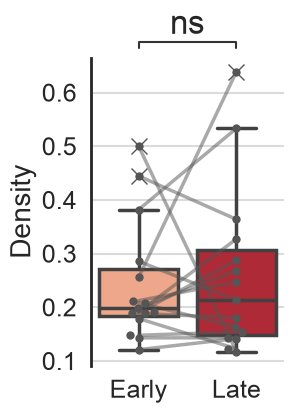

In [14]:
column = "Density"
df = df_stage[df_stage["Method"] == "Profile"].copy()
export_name = "density"
test_choice = TestChoice('t-test_paired', {'alternative': 'two-sided'})

plot_paired_boxplot(df, column, export_name, test_choice, path_plots)

## Panel D

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Early vs. Late: t-test paired samples, P_val:1.589e-02 t=2.742e+00


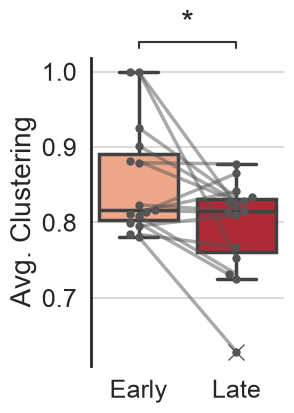

In [7]:
column = "Avg. Clustering"
df = df_stage[df_stage["Method"] == "Profile"].copy()
df = df.rename(columns={"Avg Clustering": "Avg. Clustering"})
export_name = "avg_clustering"
test_choice = TestChoice('t-test_paired', {'alternative': 'two-sided'})

plot_paired_boxplot(df, column, export_name, test_choice, path_plots)

## Panel E

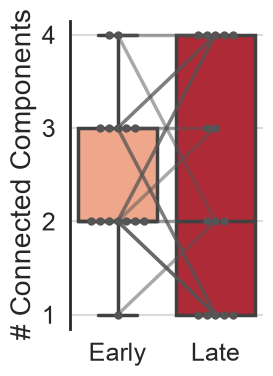

In [8]:
column = "# Connected Components"
df = df_stage[df_stage["Method"] == "Profile"].copy()
export_name = "num_conn_comp"

plot_paired_boxplot_notest(df, column, export_name, path_plots)

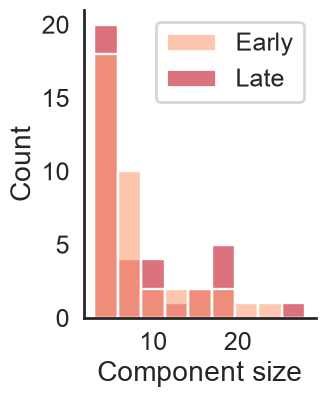

In [9]:
df = df_stage[(df_stage["Method"] == "Profile")].copy()

data = []
for row in df.iterrows():
    session = row[1]['Session']
    stage = row[1]['Stage']
    size_comm = literal_eval(row[1]['Size Conn Components'])
    for i, size in enumerate(size_comm):
        data.append([session, stage, i, size])

df_reduced = pd.DataFrame(data, columns=["Session", "Stage", "Conn Comp ID", "Conn Comp Size"])

fig, ax = plt.subplots(1, sharey=True, figsize=(3, 4))

sns.histplot(data=df_reduced, x="Conn Comp Size", hue="Stage", alpha=0.6, palette=palette_early_late)

sns.despine(left=False, bottom=False)
ax.get_legend().set_title("")
ax.grid(False)

ax.set_xlabel("Component size")

fig.savefig(path_plots + "earlylate_size_conn_comp.pdf", bbox_inches="tight", dpi=300)

## Panel F

=== Persistent pairs ===
10.18 %


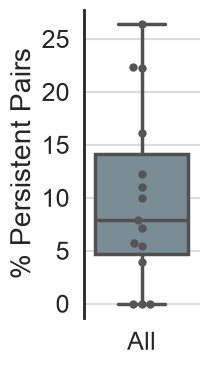

In [10]:
df = df_comparison[df_comparison["Method"] == "Profile"].copy()
df["All"] = "All"
column = "% Persistent Pairs"
export_name = "perc_persistent_pairs"

print("=== Persistent pairs ===")
print(round((df["# Persistent Pairs"].sum() / df["# Neuron Pairs"].sum()) * 100, 2), "%")

plot_single_box(df, column, export_name, path_plots)

## Panel H

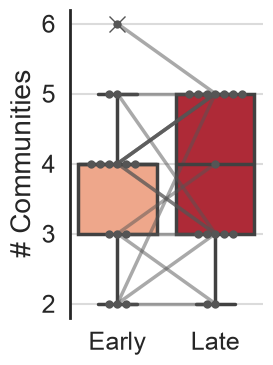

In [11]:
column = "# Communities"
df = df_stage[df_stage["Method"] == "Profile"].copy()
export_name = "numm_communities"

plot_paired_boxplot_notest(df, column, export_name, path_plots)

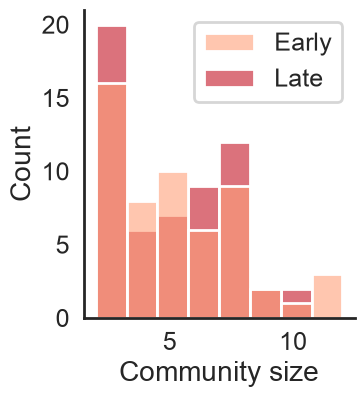

In [12]:
df = df_stage[(df_stage["Method"] == "Profile")].copy()

data = []
for row in df.iterrows():
    session = row[1]['Session']
    stage = row[1]['Stage']
    size_comm = literal_eval(row[1]['Size Communities'])
    for i, size in enumerate(size_comm):
        data.append([session, stage, i, size])

df_reduced = pd.DataFrame(data, columns=["Session", "Stage", "Comm ID", "Comm Size"])

fig, ax = plt.subplots(1, sharey=True, figsize=(3.5, 4))

sns.histplot(data=df_reduced, x="Comm Size", hue="Stage", alpha=0.6, palette=palette_early_late)

sns.despine(left=False, bottom=False)
ax.get_legend().set_title("")
ax.grid(False)
ax.set_xlabel("Community size")

fig.savefig(path_plots + "earlylate_size_comm.pdf", bbox_inches="tight", dpi=300)

## Panel I

=== Persistent assemblies ===
Max count in a single session: 3


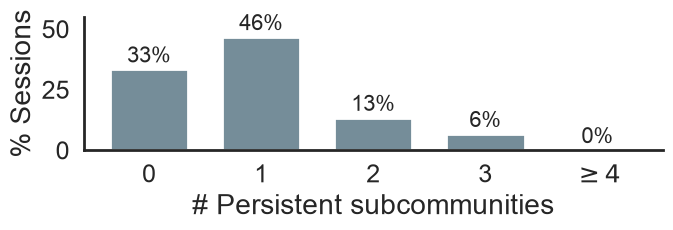

In [13]:
df = df_comparison[(df_comparison["Method"] == "Profile")].copy()
data = df["# Persistent Assemblies"]

print("=== Persistent assemblies ===")
print("Max count in a single session:", max(data))

values, bins = np.histogram(data, bins=[0, 1, 2, 3, 4, 5], density=False)
values = values / len(data)

fig, ax = plt.subplots(1, 1, figsize=(7.25, 2.75))
ax.bar(bins[:-1], values, width=0.7, color=palette_all[0])
for i, value in enumerate(values):
    ax.text(i, value+0.01, str(int(value*100)) + "%", ha="center", va="bottom", size=16)
ax.set_yticks([0, 0.25, 0.5])
ax.set_yticklabels(["0", "25", "50"])
ax.set_xticks([0, 1, 2, 3, 4])
ax.set_xticklabels(["0", "1", "2", "3", r"$\geq 4$"])
ax.set_xlabel("# Persistent subcommunities")
ax.set_ylabel("% Sessions")
ax.set_ylim([0, 0.55])
ax.grid(False)
sns.despine()

fig.tight_layout()

for format in ["pdf"]:
    fig.savefig(path_plots + "earlylate_num_pers_assem_comparison." + format, bbox_inches="tight", dpi=300)